# NAPS Poster Figures
This notebook loads the previously exported simulation CSV files and generates four publication-ready figures for the poster.

In [1]:
import numpy as np
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

results_dir = Path.cwd() / "results"
fig_dir = results_dir / "poster_figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# ---- Simulation timing controls ----
warmup_span = (0.0, 100.0)
main_span = (100.0, 130.0)
fault_span = (105.0, 110.0)
fault_label = "Line outage (branch5)"

plot_windows = {
    "freq_zoom": (100.0, 130.0),
    "wec_coupling": (100.0, 130.0),
    "multi_frequency_fault": (100.0, 130.0),
    "multi_frequency_flat": main_span,
    "bus_frequency": {
        "big": (100.0, 130.0),
        "zoom": (104.5, 112.5)
    },
    "bus_active_power_fault": {
        "big": (100.0, 130.0),
        "zoom": (104.5, 112.5)
    },
    "bus_active_power_flat": {
        "default": main_span,
    # Add per-bus overrides as needed, e.g., "bus15": (105.0, 140.0)
    },
}

def get_window(section, key=None, fallback=(0.0, 0.0)):
    data = plot_windows.get(section)
    if isinstance(data, dict):
        if key is not None and key in data:
            return data[key]
        if "default" in data:
            return data["default"]
        return fallback
    return data if data is not None else fallback

freq_window = get_window("freq_zoom")
wec_window = get_window("wec_coupling", fallback=freq_window)
multi_fault_window = get_window("multi_frequency_fault", fallback=freq_window)
multi_flat_window = get_window("multi_frequency_flat", fallback=main_span)
active_default_window = get_window("bus_active_power_fault", fallback=multi_fault_window)
plot_window_active = active_default_window
flat_active_default = get_window("bus_active_power_flat", fallback=multi_flat_window)

pre_fault_window = 1.0
post_window = 15.0
omega_suffixes = [f"_{chr(0x03C9)}", "_omega"]

print(f"Figures will be saved to: {fig_dir}")


Figures will be saved to: /Users/alex_barajas/research/MarinePowerDynamics.jl/example/results/poster_figures


In [2]:
# Load time-series data from CSV exports
df_flat_14 = pd.read_csv(results_dir / "ieee14_flat_run.csv")
df_flat_15 = pd.read_csv(results_dir / "ieee15_flat_run.csv")
df_fault_14 = pd.read_csv(results_dir / "ieee14_fault_scenario.csv")
df_fault_15 = pd.read_csv(results_dir / "ieee15_fault_scenario.csv")

time_flat = df_flat_14["time"].to_numpy()
time_fault = df_fault_14["time"].to_numpy()

assert np.allclose(time_flat, df_flat_15["time"].to_numpy()), "Flat-run time axes differ"
assert np.allclose(time_fault, df_fault_15["time"].to_numpy()), "Fault-run time axes differ"


In [3]:
def select_columns(df, suffixes):
    cols = []
    for col in df.columns:
        for suffix in suffixes:
            if col.endswith(suffix) and col not in cols:
                cols.append(col)
    return cols

def collect_bus_series(df, suffixes):
    data = {}
    for col in select_columns(df, suffixes):
        bus = col.split("_")[0]
        data[bus] = df[col].to_numpy(dtype=float)
    return data

def baseline_value(series, time, fault_start, window):
    mask = (time >= fault_start - window) & (time < fault_start)
    return float(series[mask].mean())

def max_deviation(series, time, baseline, fault_span):
    deviation = series - baseline
    during = (time >= fault_span[0]) & (time <= fault_span[1])
    after = time > fault_span[1]
    mask = during | after
    max_dev = float(np.abs(deviation[mask]).max())
    return deviation, max_dev

def rms_post_fault(deviation, time, fault_span):
    mask = time > fault_span[1]
    if not np.any(mask):
        return np.nan
    return float(np.sqrt(np.mean(np.square(deviation[mask]))))

def settling_time(deviation, time, fault_span, tol):
    start_idx = np.searchsorted(time, fault_span[1])
    for idx in range(start_idx, len(time)):
        if np.all(np.abs(deviation[idx:]) <= tol):
            return float(time[idx] - fault_span[1])
    return None

def percent_change(new, base):
    if np.isclose(base, 0.0):
        return np.nan
    return (new - base) / base * 100.0


In [4]:
# # Figure 1 - Frequency resilience comparison (window controlled via plot_windows)
# fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={'hspace': 0.25})

# # Plot the two traces
# ax_top.plot(time_fault, delta_omega_14, label="IEEE-14", color="tab:blue", linewidth=2)
# ax_top.plot(time_fault, delta_omega_15, label="IEEE-15", color="tab:red", linewidth=2)

# # Highlight the line outage period
# ax_top.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.3, label=fault_label)
# ax_bottom.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.3, label=fault_label)

# # Focus window
# ax_top.set_xlim(*freq_window)
# ax_bottom.set_xlim(*freq_window)

# ax_top.set_ylabel("Δω (rad/s)")
# ax_top.set_title(f"Frequency Resilience with WEC (Zoomed {freq_window[0]}-{freq_window[1]} s)", fontsize=13, weight="bold")
# ax_top.legend(loc="center right", frameon=False, fontsize=10, handlelength=3, labelspacing=0.3)

# # Annotate nadirs
# ax_top.annotate(f"Nadir 14 = {nadir_14:.4f}", xy=(fault_span[1] + 0.1, nadir_14), color="tab:blue", fontsize=9, va="top")
# ax_top.annotate(f"Nadir 15 = {nadir_15:.4f}", xy=(fault_span[1] + 0.1, nadir_15), color="tab:red", fontsize=9, va="top")

# metrics_lines = [
#     f"ROCOF 14 = {rocof_14:.4f} rad/s²",
#     f"ROCOF 15 = {rocof_15:.4f} rad/s²",
#     f"Settling 14 = {settle_14:.3f} s" if settle_14 else "Settling 14 = –",
#     f"Settling 15 = {settle_15:.3f} s" if settle_15 else "Settling 15 = –",
# ]
# ax_top.text(0.98, 0.02, "
# ".join(metrics_lines), transform=ax_top.transAxes,
#            ha="right", va="bottom", fontsize=9,
#            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="gray"))

# ax_bottom.plot(time_fault, freq_diff, label="IEEE-15 − IEEE-14", color="tab:green", linewidth=2)
# ax_bottom.set_xlabel("Time (s)")
# ax_bottom.set_ylabel("Δ(Δω) (rad/s)")
# ax_bottom.set_title("Difference", fontsize=12)
# ax_bottom.legend(loc="upper right", frameon=False, fontsize=9)

# fig.tight_layout()
# fig.savefig(fig_dir / "frequency_resilience_zoomed.png", dpi=300)
# plt.show()


In [5]:
# # Figure 2 - Bus-wise impact heatmaps
# freq_series_14 = collect_bus_series(df_fault_14, omega_suffixes)
# freq_series_15 = collect_bus_series(df_fault_15, omega_suffixes)
# volt_series_14 = collect_bus_series(df_fault_14, ["_v"])
# volt_series_15 = collect_bus_series(df_fault_15, ["_v"])

# common_buses = sorted(set(freq_series_14) & set(freq_series_15))

# freq_changes = []
# volt_changes = []
# for bus in common_buses:
#     base14 = baseline_value(freq_series_14[bus], time_fault, fault_span[0], pre_fault_window)
#     base15 = baseline_value(freq_series_15[bus], time_fault, fault_span[0], pre_fault_window)
#     dev14, max14 = max_deviation(freq_series_14[bus], time_fault, base14, fault_span)
#     dev15, max15 = max_deviation(freq_series_15[bus], time_fault, base15, fault_span)
#     freq_changes.append(percent_change(max15, max14))

#     series_v14 = volt_series_14.get(bus, np.zeros_like(time_fault, dtype=float))
#     series_v15 = volt_series_15.get(bus, np.zeros_like(time_fault, dtype=float))
#     vbase14 = baseline_value(series_v14, time_fault, fault_span[0], pre_fault_window)
#     vbase15 = baseline_value(series_v15, time_fault, fault_span[0], pre_fault_window)
#     _, vmax14 = max_deviation(series_v14, time_fault, vbase14, fault_span)
#     _, vmax15 = max_deviation(series_v15, time_fault, vbase15, fault_span)
#     volt_changes.append(percent_change(vmax15, vmax14))

# freq_array = np.nan_to_num(freq_changes)
# volt_array = np.nan_to_num(volt_changes)

# heat_data = np.vstack([freq_array, volt_array])
# metrics = ["Max freq deviation (%)", "Max voltage deviation (%)"]

# clim = np.max(np.abs(heat_data))
# clim = 1.0 if clim == 0 else clim

# fig, ax = plt.subplots(figsize=(10, 4))
# sns.heatmap(heat_data, cmap="coolwarm", center=0.0, vmin=-clim, vmax=clim, xticklabels=common_buses, yticklabels=metrics, ax=ax)
# ax.set_title("Bus-wise changes (IEEE15 - IEEE14)")
# ax.set_xlabel("Bus")
# fig.tight_layout()
# fig.savefig(fig_dir / "bus_impact_heatmap.png", dpi=300)
# plt.show()


In [6]:
# # Figure 3 - Generator workload redistribution
# power_series_14 = collect_bus_series(df_fault_14, ["_p"])
# power_series_15 = collect_bus_series(df_fault_15, ["_p"])

# power_buses = sorted(set(power_series_14) & set(power_series_15))

# peak_change = []
# rms_change = []
# settle_change = []
# for bus in power_buses:
#     base14 = baseline_value(power_series_14[bus], time_fault, fault_span[0], pre_fault_window)
#     base15 = baseline_value(power_series_15[bus], time_fault, fault_span[0], pre_fault_window)
#     dev14, max14 = max_deviation(power_series_14[bus], time_fault, base14, fault_span)
#     dev15, max15 = max_deviation(power_series_15[bus], time_fault, base15, fault_span)
#     peak_change.append(percent_change(max15, max14))

#     rms14 = rms_post_fault(dev14, time_fault, fault_span)
#     rms15 = rms_post_fault(dev15, time_fault, fault_span)
#     rms_change.append(percent_change(rms15, rms14))

#     settle14 = settling_time(dev14, time_fault, fault_span, 0.02)
#     settle15 = settling_time(dev15, time_fault, fault_span, 0.02)
#     if settle14 is None or settle15 is None:
#         settle_change.append(np.nan)
#     else:
#         settle_change.append(settle15 - settle14)

# peak_vals = np.nan_to_num(peak_change)
# rms_vals = np.nan_to_num(rms_change)
# settle_vals = np.nan_to_num(settle_change)

# x = np.arange(len(power_buses))
# width = 0.35

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
# ax1.bar(x - width/2, peak_vals, width, label="Peak (%)", color="tab:blue")
# ax1.bar(x + width/2, rms_vals, width, label="RMS (%)", color="tab:orange")
# ax1.set_xticks(x)
# ax1.set_xticklabels(power_buses)
# ax1.set_ylabel("Percent change (%)")
# ax1.set_title("Active power swing changes (IEEE15 - IEEE14)")
# ax1.legend()

# ax2.bar(x, settle_vals, color="tab:green")
# ax2.set_xticks(x)
# ax2.set_xticklabels(power_buses)
# ax2.set_ylabel("Delta settling (s)")
# ax2.set_title("Settling time difference")
# ax2.axhline(0.0, color="black", linewidth=0.8)

# fig.tight_layout()
# fig.savefig(fig_dir / "generator_workload_summary.png", dpi=300)
# plt.show()


In [7]:
# # Figure 4 - WEC behaviour & coupling (window controlled by plot_windows["wec_coupling"])
# power_series_15 = collect_bus_series(df_fault_15, ["_p"])
# if "bus15" in power_series_15:
#     p_wec = power_series_15["bus15"]

#     # Baseline and delta P for WEC
#     p_baseline = baseline_value(p_wec, time_fault, fault_span[0], pre_fault_window)
#     delta_p_wec = p_wec - p_baseline

#     # Window for correlation and plotting
#     mask = (time_fault >= wec_window[0]) & (time_fault <= wec_window[1])
#     window_time = time_fault[mask]
#     window_p = delta_p_wec[mask]
#     window_omega = delta_omega_15[mask]

#     if np.allclose(window_p.std(), 0) or np.allclose(window_omega.std(), 0):
#         corr_coef = np.nan
#     else:
#         corr_coef = float(np.corrcoef(window_p, window_omega)[0, 1])

#     idx_start = np.searchsorted(time_fault, wec_window[0])
#     idx_end = np.searchsorted(time_fault, min(wec_window[1], fault_span[0] + post_window))
#     idx_end = max(idx_end, idx_start + 1)
#     energy_joules = float(np.trapz(delta_p_wec[idx_start:idx_end], time_fault[idx_start:idx_end]))

#     fig, (ax_main, ax_scatter) = plt.subplots(2, 1, figsize=(9, 6),
#                                              gridspec_kw={'hspace': 0.28, 'height_ratios': [2, 1]})

#     ln1, = ax_main.plot(time_fault, delta_p_wec, label="P_WEC (baseline-subtracted)", color="tab:blue", linewidth=2)
#     ax_main.set_ylabel("Active power (p.u.)")
#     ax_main.set_title(f"WEC Power Exchange vs Frequency (Zoomed {wec_window[0]}-{wec_window[1]} s)",
#                       fontsize=13, weight="bold")

#     ax_twin = ax_main.twinx()
#     ln2, = ax_twin.plot(time_fault, delta_omega_15, label="Δω (IEEE-15)", color="tab:red", linewidth=2)
#     ax_twin.set_ylabel("Δω (rad/s)")

#     ax_main.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.3, label=fault_label)
#     ax_main.set_xlim(*wec_window)

#     handles = [ln1, ln2]
#     ax_main.legend(handles, [h.get_label() for h in handles], loc="center right", frameon=False, fontsize=10)

#     metrics_lines = [
#         f"corr = {corr_coef:.3f}" if np.isfinite(corr_coef) else "corr = –",
#         f"Energy (0–{post_window:.1f} s) = {energy_joules/1e6:.3f} MJ",
#     ]
#     ax_main.text(0.98, 0.02, "
# ".join(metrics_lines), transform=ax_main.transAxes,
#                  ha="right", va="bottom", fontsize=9,
#                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="gray"))

#     ax_scatter.scatter(window_omega, window_p, s=12)
#     ax_scatter.set_xlabel("Δω (rad/s)")
#     ax_scatter.set_ylabel("P_WEC (p.u.)")
#     ax_scatter.set_title("Correlation Window", fontsize=12)

#     fig.tight_layout()
#     fig.savefig(fig_dir / "wec_coupling_analysis.png", dpi=300)
#     plt.show()
# else:
#     print("bus15 data not available in IEEE-15 results")


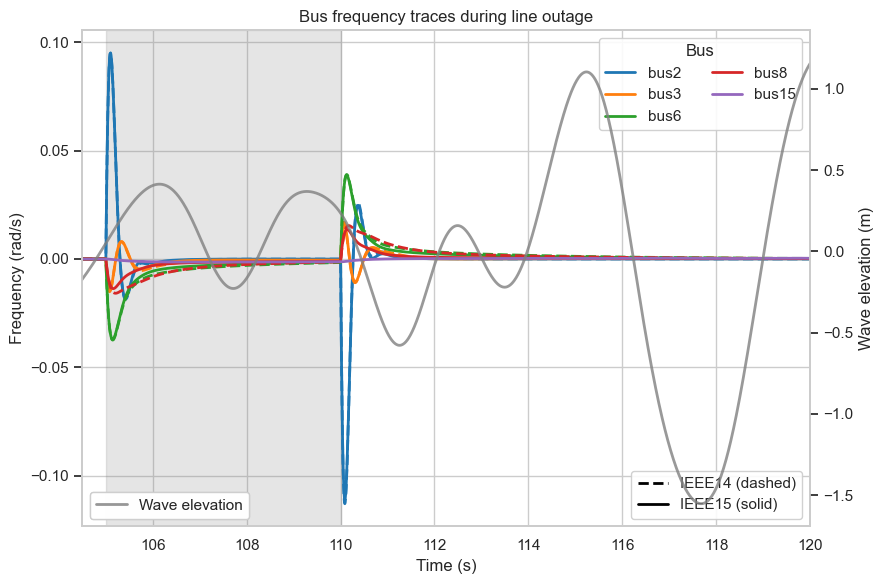

In [54]:
# Figure 5 - Bus frequency traces with wave elevation overlay
freq_buses = ["bus2", "bus3", "bus6", "bus8", "bus15"]
colors = {
    "bus2": "tab:blue",
    "bus3": "tab:orange",
    "bus6": "tab:green",
    "bus8": "tab:red",
    "bus15": "tab:purple",
}

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_series_14 = collect_bus_series(df_fault_14, omega_suffixes)
freq_series_15 = collect_bus_series(df_fault_15, omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# --- Frequency traces for each bus ---
for bus in freq_buses:
    color = colors.get(bus)
    if bus in freq_series_14:
        ax_freq.plot(time_fault, freq_series_14[bus], linestyle="--", linewidth=2, color=color)
    if bus in freq_series_15:
        ax_freq.plot(time_fault, freq_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_freq.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axis labels and limits ---
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus frequency traces during line outage")
ax_freq.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handles = [plt.Line2D([0], [0], color=colors[bus], lw=2) for bus in freq_buses]
bus_legend = ax_freq.legend(bus_handles, freq_buses, loc="upper right", ncol=2, title="Bus")
ax_freq.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = [
    plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"),
    plt.Line2D([0], [0], color="black", linestyle="-",  linewidth=2, label="IEEE15 (solid)"),
]
style_legend = ax_freq.legend(handles=style_handles, loc="lower right")
ax_freq.add_artist(style_legend)

# --- Twin y-axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)   # keep wave line visible
ax_wave.patch.set_visible(False)                # transparent background
ax_wave.grid(False)

wave_mask = (wave_time >= multi_fault_window[0]) & (wave_time <= multi_fault_window[1])
wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
ax_wave.set_ylabel("Wave elevation (m)")

# --- Wave legend ---
wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="lower left")
ax_freq.add_artist(wave_legend)

# --- Keep all legends on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    lg.set_zorder(50)
    lg.get_frame().set_facecolor("white")
    lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus_multi_frequency_fault.png", dpi=300)
plt.show()

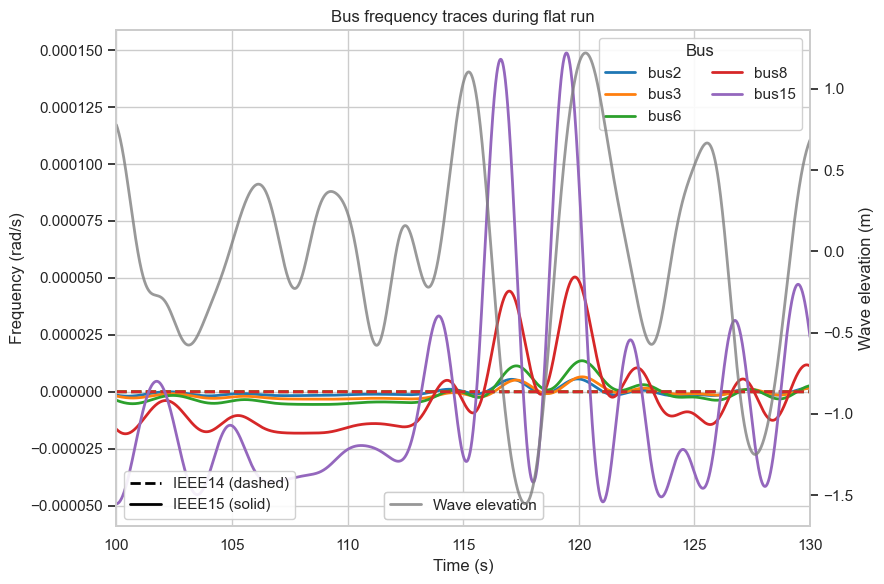

In [9]:
# Figure 6 - Flat-run bus frequency traces with wave elevation overlay
freq_buses = ["bus2", "bus3", "bus6", "bus8", "bus15"]
colors = {
    "bus2": "tab:blue",
    "bus3": "tab:orange",
    "bus6": "tab:green",
    "bus8": "tab:red",
    "bus15": "tab:purple",
}

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_flat_14 = collect_bus_series(df_flat_14, omega_suffixes)
freq_flat_15 = collect_bus_series(df_flat_15, omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# --- Frequency traces ---
for bus in freq_buses:
    color = colors.get(bus)
    if bus in freq_flat_14:
        ax_freq.plot(time_flat, freq_flat_14[bus], linestyle="--", linewidth=2, color=color)
    if bus in freq_flat_15:
        ax_freq.plot(time_flat, freq_flat_15[bus], linestyle="-", linewidth=2, color=color)

# --- Axes labels and limits ---
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus frequency traces during flat run")
ax_freq.set_xlim(*multi_flat_window)

# --- Legends ---
bus_handles = [plt.Line2D([0], [0], color=colors[bus], lw=2) for bus in freq_buses]
bus_legend = ax_freq.legend(bus_handles, freq_buses, loc="upper right", ncol=2, title="Bus")
ax_freq.add_artist(bus_legend)

style_handles = [
    plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"),
    plt.Line2D([0], [0], color="black", linestyle="-",  linewidth=2, label="IEEE15 (solid)"),
]
style_legend = ax_freq.legend(handles=style_handles, loc="lower left")
ax_freq.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)
ax_wave.patch.set_visible(False)
ax_wave.grid(False)

wave_mask = (wave_time >= multi_flat_window[0]) & (wave_time <= multi_flat_window[1])
wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
ax_wave.set_ylabel("Wave elevation (m)")

# --- Wave legend ---
wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="lower center")
ax_freq.add_artist(wave_legend)

# --- Bring all legends to the top layer ---
for lg in [bus_legend, style_legend, wave_legend]:
    lg.set_zorder(50)
    lg.get_frame().set_facecolor("white")
    lg.get_frame().set_alpha(0.9)

# --- Layout and save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus_multi_frequency_flat.png", dpi=300)
plt.show()

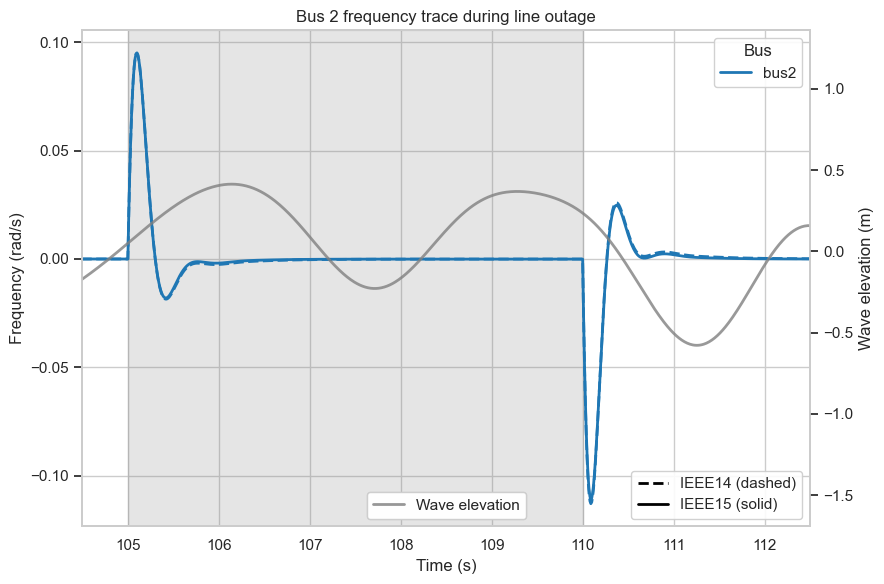

In [50]:
# Figure for bus3 frequency trace with wave elevation overlay
bus = "bus2"
color = "tab:blue"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_series_14 = collect_bus_series(df_fault_14, omega_suffixes)
freq_series_15 = collect_bus_series(df_fault_15, omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# --- Frequency traces ---
if bus in freq_series_14:
    ax_freq.plot(time_fault, freq_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in freq_series_15:
    ax_freq.plot(time_fault, freq_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Labels, window, fault span ---
ax_freq.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus 2 frequency trace during line outage")
ax_freq.set_xlim(*get_window("bus_frequency", "zoom", multi_fault_window))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_freq.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_freq.add_artist(bus_legend)

# --- Style legend ---
style_handles = []
if bus in freq_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in freq_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_freq.legend(handles=style_handles, loc="lower right")
    ax_freq.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)   # wave line visible
ax_wave.patch.set_visible(False)                # transparent background
ax_wave.grid(False)

wavem = get_window("bus_frequency", "bus2", multi_fault_window)
wave_mask = (wave_time >= wavem[0]) & (wave_time <= wavem[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_freq.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends are on top ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus2_frequency_fault.png", dpi=300)
plt.show()

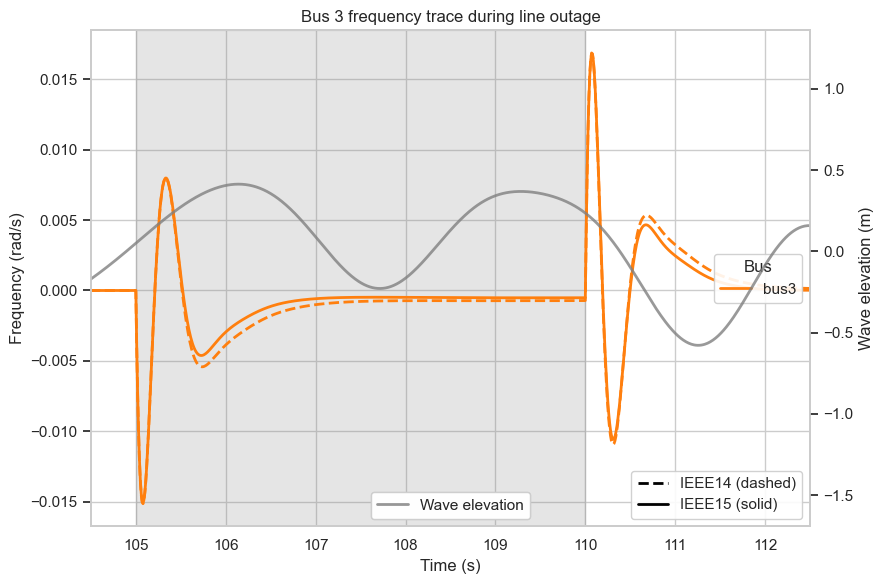

In [10]:
# Figure for bus3 frequency trace with wave elevation overlay
bus = "bus3"
color = "tab:orange"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_series_14 = collect_bus_series(df_fault_14, omega_suffixes)
freq_series_15 = collect_bus_series(df_fault_15, omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# --- Frequency traces ---
if bus in freq_series_14:
    ax_freq.plot(time_fault, freq_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in freq_series_15:
    ax_freq.plot(time_fault, freq_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Labels, window, fault span ---
ax_freq.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus 3 frequency trace during line outage")
ax_freq.set_xlim(*get_window("bus_frequency", "zoom", multi_fault_window))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_freq.legend([bus_handle], [bus], loc="center right", title="Bus")
ax_freq.add_artist(bus_legend)

# --- Style legend ---
style_handles = []
if bus in freq_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in freq_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_freq.legend(handles=style_handles, loc="lower right")
    ax_freq.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)   # wave line visible
ax_wave.patch.set_visible(False)                # transparent background
ax_wave.grid(False)

wavem = get_window("bus_frequency", "bus3", multi_fault_window)
wave_mask = (wave_time >= wavem[0]) & (wave_time <= wavem[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_freq.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends are on top ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus3_frequency_fault.png", dpi=300)
plt.show()

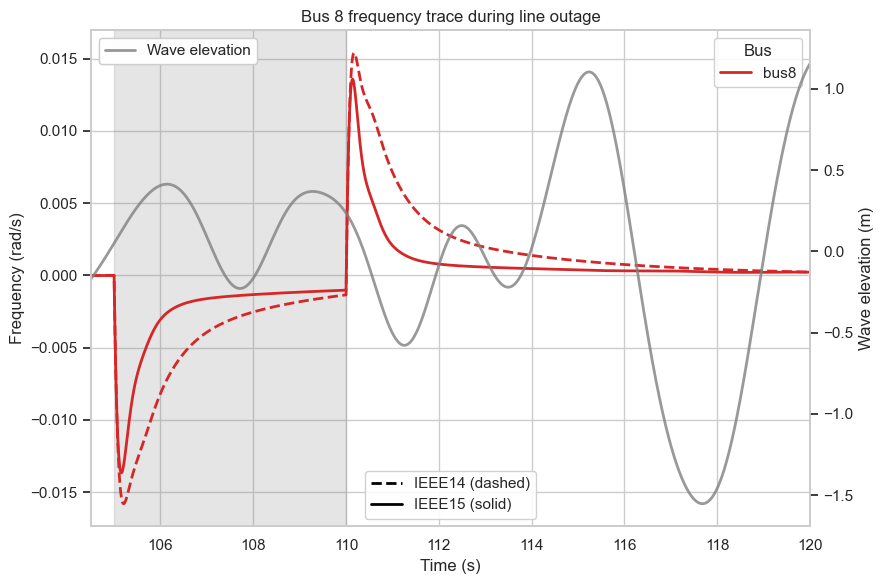

In [41]:
# Figure for bus8 frequency trace with wave elevation overlay
bus = "bus8"
color = "tab:red"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_series_14 = collect_bus_series(df_fault_14, omega_suffixes)
freq_series_15 = collect_bus_series(df_fault_15, omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# Frequency traces
if bus in freq_series_14:
    ax_freq.plot(time_fault, freq_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in freq_series_15:
    ax_freq.plot(time_fault, freq_series_15[bus], linestyle="-", linewidth=2, color=color)

# Labels, window, fault span
ax_freq.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus 8 frequency trace during line outage")
ax_freq.set_xlim((104.5, 120))

# Legends: bus
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_freq.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_freq.add_artist(bus_legend)

# Legends: style
style_handles = []
if bus in freq_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in freq_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_freq.legend(handles=style_handles, loc="lower center")
    ax_freq.add_artist(style_legend)

# Twin axis for wave elevation — keep it on TOP, transparent, no grid
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)   # ensure wave line is visible
ax_wave.patch.set_visible(False)                # transparent background
ax_wave.grid(False)

wavem = get_window("bus_frequency", "bus8", multi_fault_window)
wave_mask = (wave_time >= wavem[0]) & (wave_time <= wavem[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="upper left")
    ax_freq.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# Ensure all legends stay on top and readable
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

fig.tight_layout()
fig.savefig(fig_dir / "bus8_frequency_fault.png", dpi=300)
plt.show()

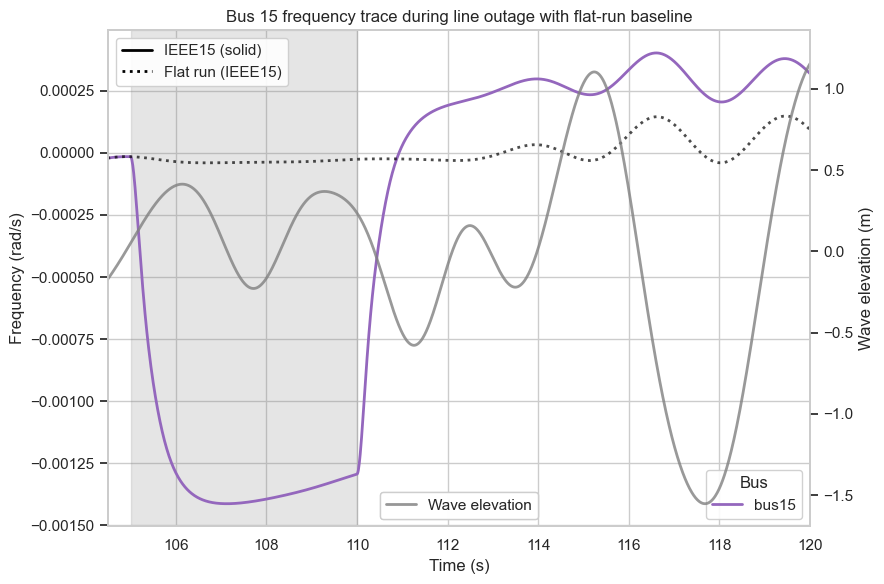

In [43]:
# Figure for bus15 frequency trace with wave elevation overlay
bus = "bus15"
color = "tab:purple"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_fault_14 = collect_bus_series(df_fault_14, omega_suffixes)
freq_fault_15 = collect_bus_series(df_fault_15, omega_suffixes)
freq_flat_15  = collect_bus_series(df_flat_15,  omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# --- Frequency traces ---
if bus in freq_fault_14:
    ax_freq.plot(time_fault, freq_fault_14[bus], linestyle="--", linewidth=2, color=color)
if bus in freq_fault_15:
    ax_freq.plot(time_fault, freq_fault_15[bus], linestyle="-", linewidth=2, color=color)
if bus in freq_flat_15:
    ax_freq.plot(time_flat,  freq_flat_15[bus],  linestyle=":",  linewidth=2, color="black", alpha=0.7)

# --- Labels & window ---
ax_freq.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus 15 frequency trace during line outage with flat-run baseline")
ax_freq.set_xlim((104.5, 120))

# --- Legends ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_freq.legend([bus_handle], [bus], loc="lower right", title="Bus")
ax_freq.add_artist(bus_legend)

style_handles = []
if bus in freq_fault_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in freq_fault_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-",  linewidth=2, label="IEEE15 (solid)"))
if bus in freq_flat_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle=":",  linewidth=2, label="Flat run (IEEE15)"))
if style_handles:
    style_legend = ax_freq.legend(handles=style_handles, loc="upper left")
    ax_freq.add_artist(style_legend)

# --- Wave elevation (twin axis) ---
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)   # on top so the line is visible
ax_wave.patch.set_visible(False)                # transparent background
ax_wave.grid(False)

wavem = get_window("bus_frequency", "bus15", multi_fault_window)
wave_mask = (wave_time >= wavem[0]) & (wave_time <= wavem[1])
if np.any(wave_mask):
    wave_line, = ax_wave.plot(
        wave_time[wave_mask],
        wave_elev[wave_mask],
        color="gray",
        alpha=0.8,
        linewidth=2,
        label="Wave elevation"
    )

ax_wave.set_ylabel("Wave elevation (m)")

# --- Wave legend ---
if np.any(wave_mask):
    wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_freq.add_artist(wave_legend)

# --- Ensure all legends stay on top ---
for legend in fig.legends + [bus_legend, *([style_legend] if style_handles else []), *([wave_legend] if np.any(wave_mask) else [])]:
    legend.set_zorder(50)
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus15_frequency_fault_flat.png", dpi=300)
plt.show()

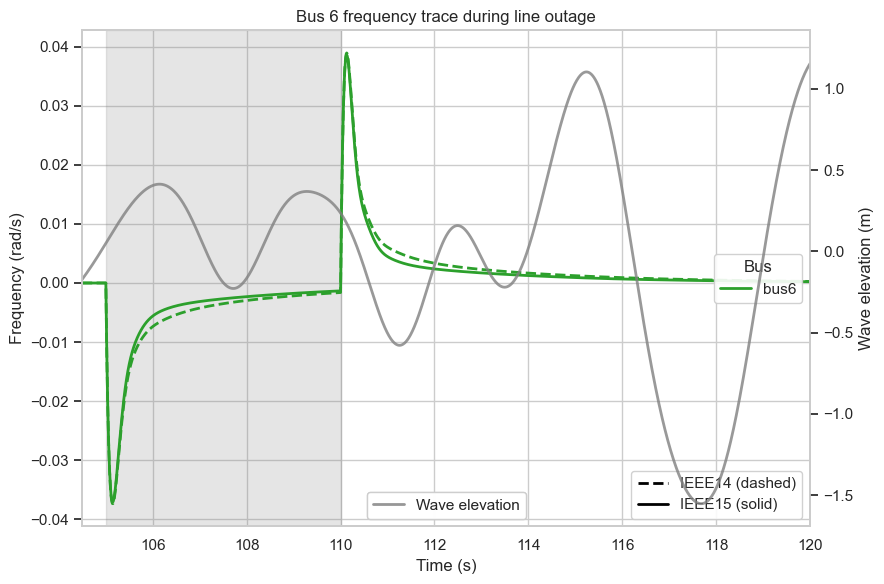

In [27]:
# Figure for bus6 frequency trace with wave elevation overlay
bus = "bus6"
color = "tab:green"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_series_14 = collect_bus_series(df_fault_14, omega_suffixes)
freq_series_15 = collect_bus_series(df_fault_15, omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# --- Frequency traces ---
if bus in freq_series_14:
    ax_freq.plot(time_fault, freq_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in freq_series_15:
    ax_freq.plot(time_fault, freq_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Labels, window, fault span ---
ax_freq.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus 6 frequency trace during line outage")
ax_freq.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_freq.legend([bus_handle], [bus], loc="center right", title="Bus")
ax_freq.add_artist(bus_legend)

# --- Style legend ---
style_handles = []
if bus in freq_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in freq_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_freq.legend(handles=style_handles, loc="lower right")
    ax_freq.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)   # wave line visible
ax_wave.patch.set_visible(False)                # transparent background
ax_wave.grid(False)

wavem = get_window("bus_frequency", "bus6", multi_fault_window)
wave_mask = (wave_time >= wavem[0]) & (wave_time <= wavem[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_freq.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends are on top ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus6_frequency_fault.png", dpi=300)
plt.show()

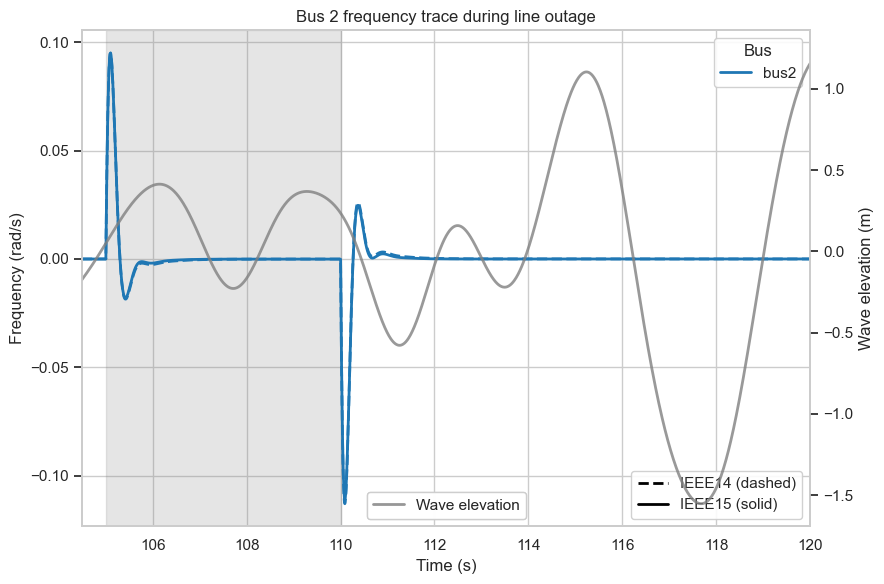

In [53]:
# Figure for bus2 frequency trace with wave elevation overlay
bus = "bus2"
color = "tab:blue"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

freq_series_14 = collect_bus_series(df_fault_14, omega_suffixes)
freq_series_15 = collect_bus_series(df_fault_15, omega_suffixes)

fig, ax_freq = plt.subplots(figsize=(9, 6))

# --- Frequency traces ---
if bus in freq_series_14:
    ax_freq.plot(time_fault, freq_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in freq_series_15:
    ax_freq.plot(time_fault, freq_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Labels, window, fault span ---
ax_freq.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)
ax_freq.set_xlabel("Time (s)")
ax_freq.set_ylabel("Frequency (rad/s)")
ax_freq.set_title("Bus 2 frequency trace during line outage")
ax_freq.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_freq.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_freq.add_artist(bus_legend)

# --- Style legend ---
style_handles = []
if bus in freq_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in freq_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_freq.legend(handles=style_handles, loc="lower right")
    ax_freq.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_freq.twinx()
ax_wave.set_zorder(ax_freq.get_zorder() + 1)   # wave line visible
ax_wave.patch.set_visible(False)                # transparent background
ax_wave.grid(False)

wavem = get_window("bus_frequency", "bus2", multi_fault_window)
wave_mask = (wave_time >= wavem[0]) & (wave_time <= wavem[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_freq.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_freq.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends are on top ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus2_frequency_fault.png", dpi=300)
plt.show()

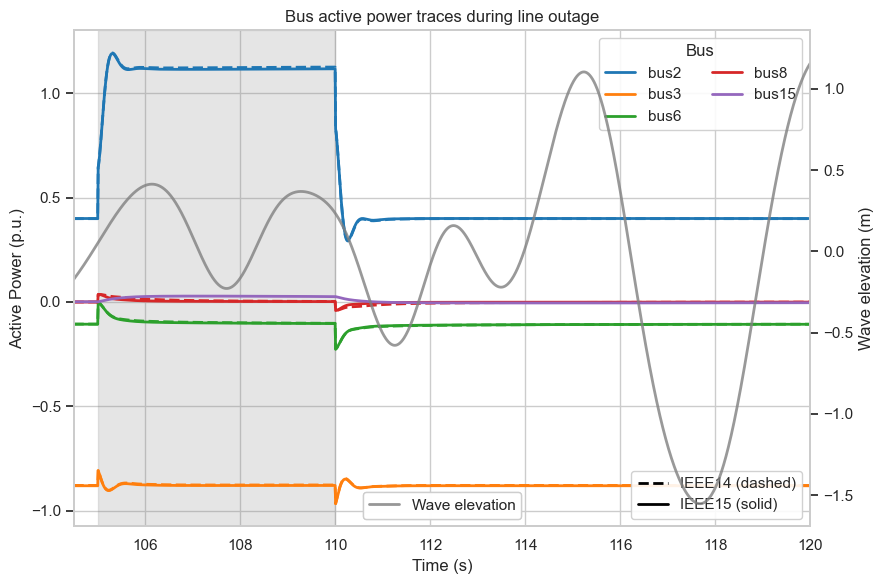

In [55]:
# Figure 5 - Bus active power traces with wave elevation overlay
# (same layout/legends/layering as your frequency figure)

freq_buses = ["bus2", "bus3", "bus6", "bus8", "bus15"]
colors = {
    "bus2": "tab:blue",
    "bus3": "tab:orange",
    "bus6": "tab:green",
    "bus8": "tab:red",
    "bus15": "tab:purple",
}

# Use your actual column suffix for active power here
p_suffixes = ["_p"]  # change if your column naming differs

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Collect active power series for each bus from both cases
p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces for each bus ---
for bus in freq_buses:
    color = colors.get(bus)
    if bus in p_series_14:
        ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
    if bus in p_series_15:
        ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axis labels and limits ---
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus active power traces during line outage")
ax_p.set_xlim((104.5, 120.0))

# --- Bus legend ---
bus_handles = [plt.Line2D([0], [0], color=colors[bus], lw=2) for bus in freq_buses]
bus_legend = ax_p.legend(bus_handles, freq_buses, loc="upper right", ncol=2, title="Bus")
ax_p.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = [
    plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"),
    plt.Line2D([0], [0], color="black", linestyle="-",  linewidth=2, label="IEEE15 (solid)"),
]
style_legend = ax_p.legend(handles=style_handles, loc="lower right")
ax_p.add_artist(style_legend)

# --- Twin y-axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)   # keep wave line visible
ax_wave.patch.set_visible(False)            # transparent background
ax_wave.grid(False)

wave_mask = (wave_time >= plot_window_active[0]) & (wave_time <= plot_window_active[1])
wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
ax_wave.set_ylabel("Wave elevation (m)")

# --- Wave legend ---
wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower center")
ax_p.add_artist(wave_legend)

# --- Keep all legends on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    lg.set_zorder(50)
    lg.get_frame().set_facecolor("white")
    lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus_multi_active_power_fault.png", dpi=300)
plt.show()

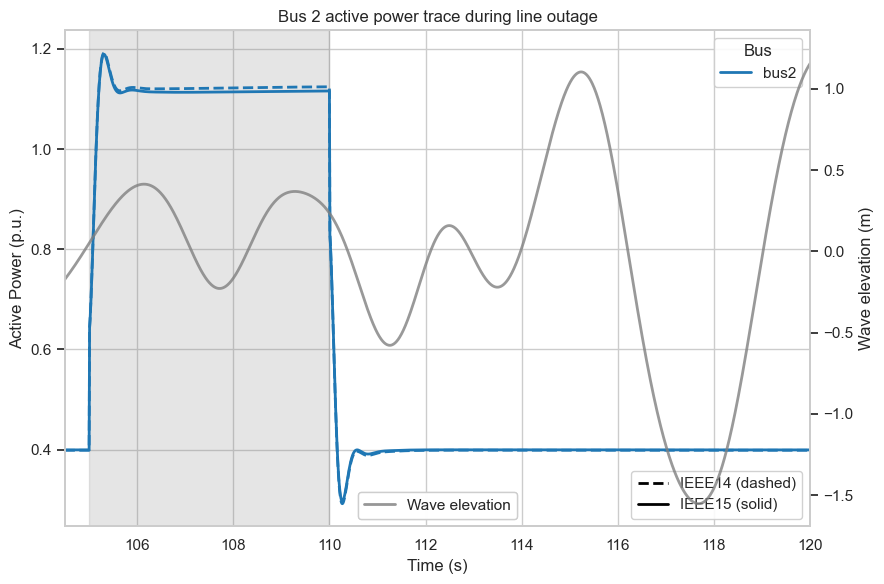

In [31]:
# Figure – Bus 2 active power trace with wave elevation overlay
bus = "bus2"
color = "tab:blue"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Use correct suffix for active power columns
p_suffixes = ["_p"]  # update if your naming differs

p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces for Bus 2 ---
if bus in p_series_14:
    ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in p_series_15:
    ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axes and limits ---
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus 2 active power trace during line outage")
ax_p.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_p.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_p.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = []
if bus in p_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in p_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_p.legend(handles=style_handles, loc="lower right")
    ax_p.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)
ax_wave.patch.set_visible(False)
ax_wave.grid(False)

win = get_window("bus_active_power_fault", "bus2", active_default_window)
wave_mask = (wave_time >= win[0]) & (wave_time <= win[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(
        wave_time[wave_mask],
        wave_elev[wave_mask],
        color="gray",
        alpha=0.8,
        linewidth=2
    )
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_p.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends are on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus2_active_power_fault.png", dpi=300)
plt.show()

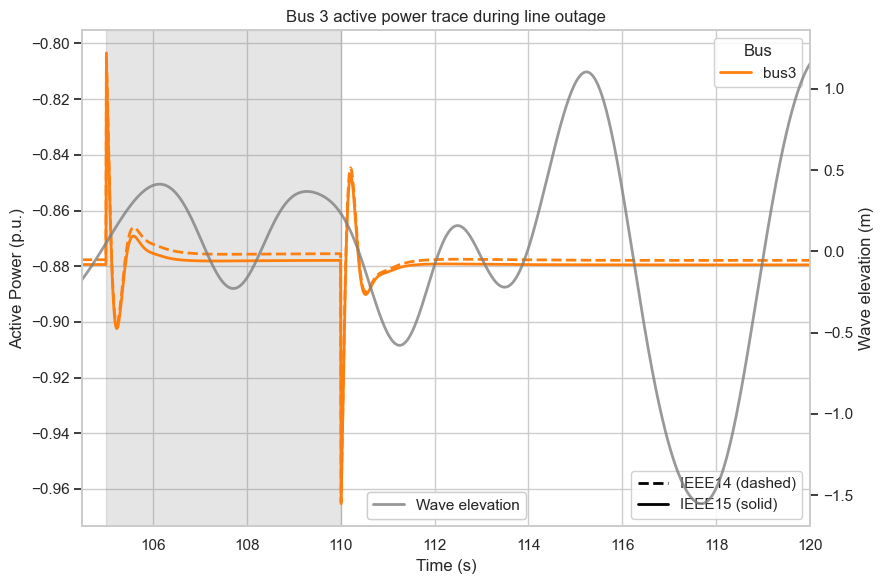

In [32]:
# Figure – Bus 3 active power trace with wave elevation overlay
bus = "bus3"
color = "tab:orange"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Use correct suffix for active power columns
p_suffixes = ["_p"]  # update if your column naming differs

p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces for Bus 3 ---
if bus in p_series_14:
    ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in p_series_15:
    ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axes and limits ---
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus 3 active power trace during line outage")
ax_p.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_p.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_p.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = []
if bus in p_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in p_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_p.legend(handles=style_handles, loc="lower right")
    ax_p.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)   # wave line visible
ax_wave.patch.set_visible(False)            # transparent background
ax_wave.grid(False)

win = get_window("bus_active_power_fault", "bus3", active_default_window)
wave_mask = (wave_time >= win[0]) & (wave_time <= win[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(
        wave_time[wave_mask],
        wave_elev[wave_mask],
        color="gray",
        alpha=0.8,
        linewidth=2
    )
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_p.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends are on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus3_active_power_fault.png", dpi=300)
plt.show()

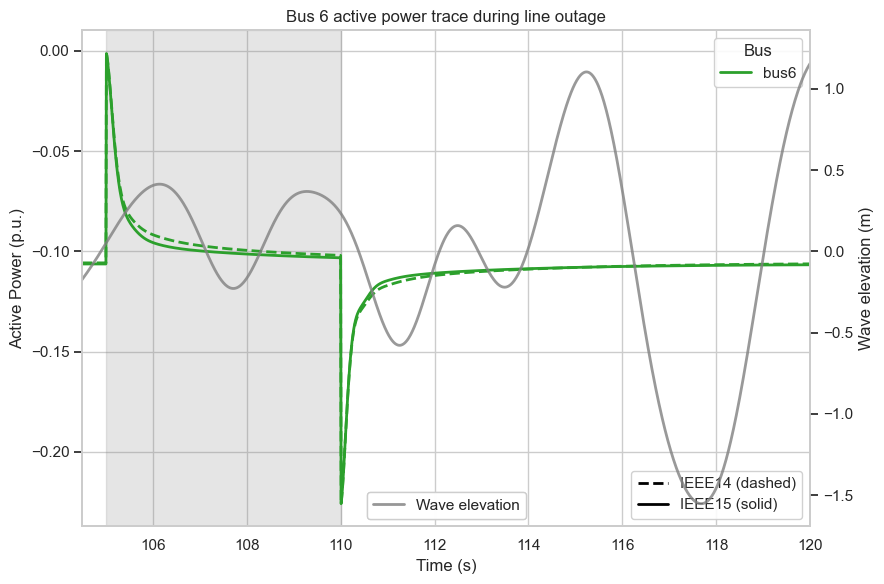

In [33]:
# Figure – Bus 6 active power trace with wave elevation overlay
bus = "bus6"
color = "tab:green"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Active power suffix (update if your naming differs)
p_suffixes = ["_p"]

p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces for Bus 6 ---
if bus in p_series_14:
    ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in p_series_15:
    ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axes and limits ---
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus 6 active power trace during line outage")
ax_p.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_p.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_p.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = []
if bus in p_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"))
if bus in p_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_p.legend(handles=style_handles, loc="lower right")
    ax_p.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)
ax_wave.patch.set_visible(False)
ax_wave.grid(False)

win = get_window("bus_active_power_fault", "bus6", active_default_window)
wave_mask = (wave_time >= win[0]) & (wave_time <= win[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_p.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends are on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus6_active_power_fault.png", dpi=300)
plt.show()

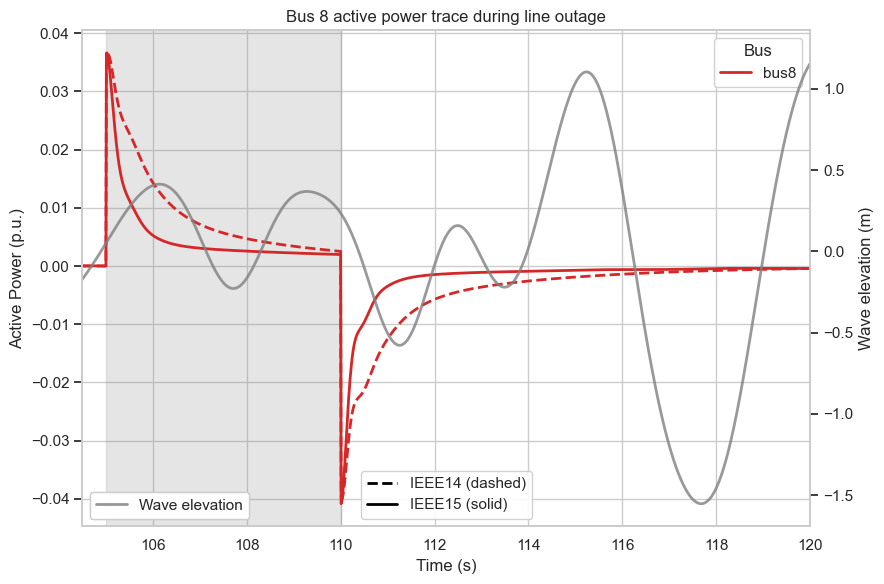

In [46]:
# Figure – Bus 8 active power trace with wave elevation overlay
bus = "bus8"
color = "tab:red"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Active power suffix (update if naming differs)
p_suffixes = ["_p"]

p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces for Bus 8 ---
if bus in p_series_14:
    ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in p_series_15:
    ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axes and limits ---
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus 8 active power trace during line outage")
ax_p.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_p.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_p.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = []
if bus in p_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--",
                                    linewidth=2, label="IEEE14 (dashed)"))
if bus in p_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-",
                                    linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_p.legend(handles=style_handles, loc="lower center")
    ax_p.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)
ax_wave.patch.set_visible(False)
ax_wave.grid(False)

win = get_window("bus_active_power_fault", "bus8", active_default_window)
wave_mask = (wave_time >= win[0]) & (wave_time <= win[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask],
                              color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower left")
    ax_p.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends stay on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus8_active_power_fault.png", dpi=300)
plt.show()

In [20]:
# # Figure 7 - Bus 9 active power trace with wave elevation overlay
# bus = "bus9"
# color = "tab:blue"

# wave_path = Path("RM3") / "linear_pto_heave.json"
# wave_data = json.loads(wave_path.read_text())
# wave_time = np.array(wave_data["data"]["time"], dtype=float)
# wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# # Use your column suffix for active power
# p_suffixes = ["_p"]  # adjust if your naming differs

# # Active power series from both cases
# p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
# p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

# fig, ax_p = plt.subplots(figsize=(9, 6))

# # --- Active power traces for bus 9 ---
# if bus in p_series_14:
#     ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
# if bus in p_series_15:
#     ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# # --- Fault window ---
# ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# # --- Axis labels and limits ---
# ax_p.set_xlabel("Time (s)")
# ax_p.set_ylabel("Active Power (p.u.)")
# ax_p.set_title("Bus 9 active power trace during line outage")
# ax_p.set_xlim(*get_window("bus_active_power_fault", "bus9", active_default_window))

# # --- Bus legend ---
# bus_handle = plt.Line2D([0], [0], color=color, lw=2)
# bus_legend = ax_p.legend([bus_handle], [bus], loc="center right", title="Bus")
# ax_p.add_artist(bus_legend)

# # --- Style legend (IEEE14 vs IEEE15) ---
# style_handles = [
#     plt.Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="IEEE14 (dashed)"),
#     plt.Line2D([0], [0], color="black", linestyle="-",  linewidth=2, label="IEEE15 (solid)"),
# ]
# style_legend = ax_p.legend(handles=style_handles, loc="lower right")
# ax_p.add_artist(style_legend)

# # --- Twin y-axis for wave elevation (on top, transparent, no grid) ---
# ax_wave = ax_p.twinx()
# ax_wave.set_zorder(ax_p.get_zorder() + 1)   # keep wave line visible
# ax_wave.patch.set_visible(False)            # transparent background
# ax_wave.grid(False)

# win = get_window("bus_active_power_fault", "bus9", active_default_window)
# wave_mask = (wave_time >= win[0]) & (wave_time <= win[1])
# wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask], color="gray", alpha=0.8, linewidth=2)
# ax_wave.set_ylabel("Wave elevation (m)")

# # --- Wave legend ---
# wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower center")
# ax_p.add_artist(wave_legend)

# # --- Keep all legends on top and readable ---
# for lg in [bus_legend, style_legend, wave_legend]:
#     lg.set_zorder(50)
#     lg.get_frame().set_facecolor("white")
#     lg.get_frame().set_alpha(0.9)

# # --- Layout & save ---
# fig.tight_layout()
# fig.savefig(fig_dir / "bus9_active_power_fault.png", dpi=300)
# plt.show()

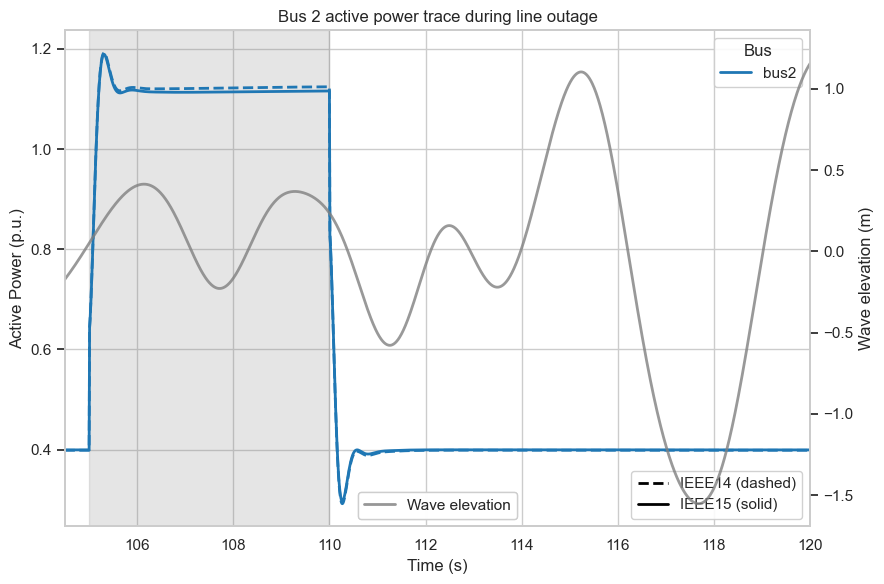

In [51]:
# Figure – Bus 8 active power trace with wave elevation overlay
bus = "bus2"
color = "tab:blue"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Active power suffix (update if naming differs)
p_suffixes = ["_p"]

p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces for Bus 8 ---
if bus in p_series_14:
    ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in p_series_15:
    ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axes and limits ---
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus 2 active power trace during line outage")
ax_p.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_p.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_p.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = []
if bus in p_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--",
                                    linewidth=2, label="IEEE14 (dashed)"))
if bus in p_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-",
                                    linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_p.legend(handles=style_handles, loc="lower right")
    ax_p.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)
ax_wave.patch.set_visible(False)
ax_wave.grid(False)

win = get_window("bus_active_power_fault", "bus2", active_default_window)
wave_mask = (wave_time >= win[0]) & (wave_time <= win[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask],
                              color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_p.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends stay on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus2_active_power_fault.png", dpi=300)
plt.show()

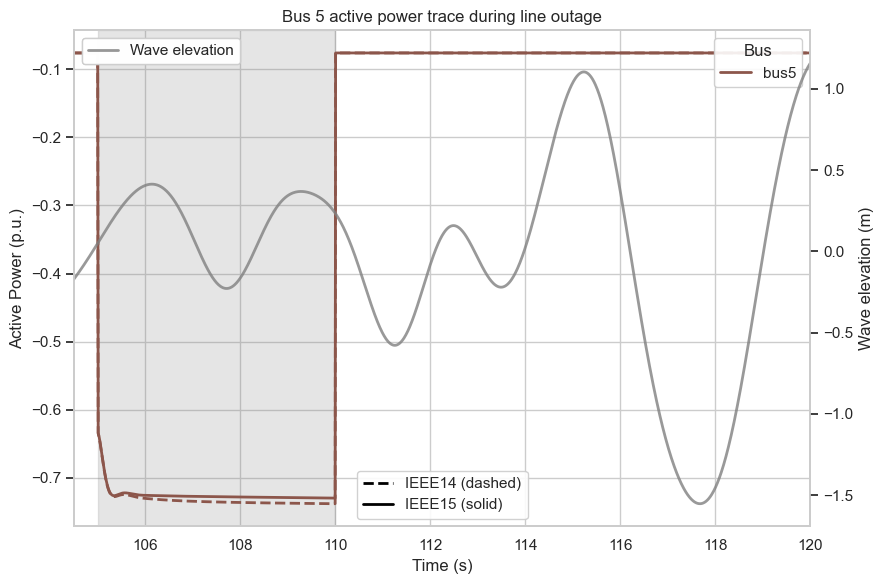

In [47]:
# Figure – Bus 8 active power trace with wave elevation overlay
bus = "bus5"
color = "tab:brown"

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Active power suffix (update if naming differs)
p_suffixes = ["_p"]

p_series_14 = collect_bus_series(df_fault_14, p_suffixes)
p_series_15 = collect_bus_series(df_fault_15, p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces for Bus 8 ---
if bus in p_series_14:
    ax_p.plot(time_fault, p_series_14[bus], linestyle="--", linewidth=2, color=color)
if bus in p_series_15:
    ax_p.plot(time_fault, p_series_15[bus], linestyle="-", linewidth=2, color=color)

# --- Fault window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)

# --- Axes and limits ---
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus 5 active power trace during line outage")
ax_p.set_xlim((104.5, 120))

# --- Bus legend ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_p.legend([bus_handle], [bus], loc="upper right", title="Bus")
ax_p.add_artist(bus_legend)

# --- Style legend (IEEE14 vs IEEE15) ---
style_handles = []
if bus in p_series_14:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="--",
                                    linewidth=2, label="IEEE14 (dashed)"))
if bus in p_series_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle="-",
                                    linewidth=2, label="IEEE15 (solid)"))
style_legend = None
if style_handles:
    style_legend = ax_p.legend(handles=style_handles, loc="lower center")
    ax_p.add_artist(style_legend)

# --- Twin axis for wave elevation (on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)
ax_wave.patch.set_visible(False)
ax_wave.grid(False)

win = get_window("bus_active_power_fault", "bus5", active_default_window)
wave_mask = (wave_time >= win[0]) & (wave_time <= win[1])
wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(wave_time[wave_mask], wave_elev[wave_mask],
                              color="gray", alpha=0.8, linewidth=2)
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="upper left")
    ax_p.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends stay on top and readable ---
for lg in [bus_legend, style_legend, wave_legend]:
    if lg is not None:
        lg.set_zorder(50)
        lg.get_frame().set_facecolor("white")
        lg.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus5_active_power_fault.png", dpi=300)
plt.show()

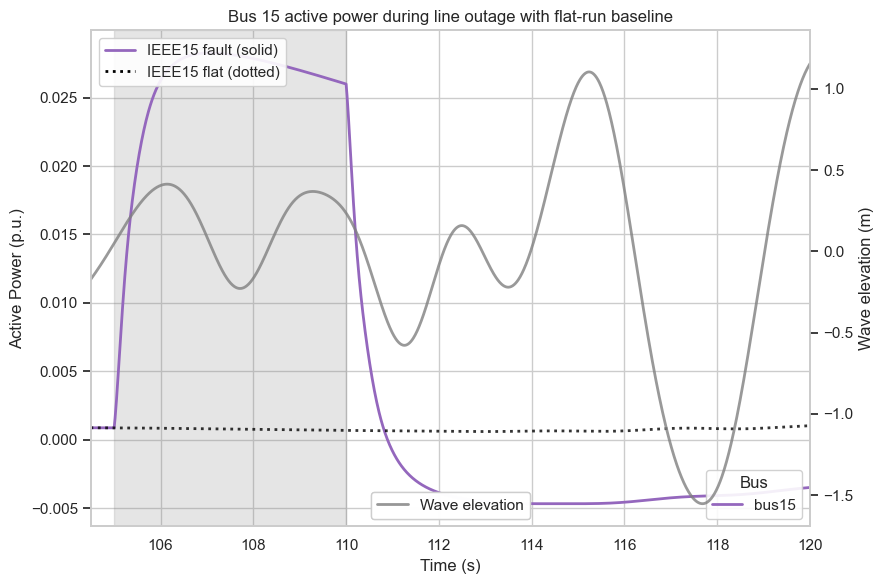

In [45]:
# Figure – Bus 15 active power trace during line outage with flat-run baseline
bus = "bus15"
color = "tab:purple"  # bus color for fault trace

wave_path = Path("RM3") / "linear_pto_heave.json"
wave_data = json.loads(wave_path.read_text())
wave_time = np.array(wave_data["data"]["time"], dtype=float)
wave_elev = np.array(wave_data["data"]["waveElevation"], dtype=float)

# Active power suffix (adjust if your naming differs)
p_suffixes = ["_p"]

# Series: IEEE15 fault and IEEE15 flat (no IEEE14 for bus15)
p_fault_15 = collect_bus_series(df_fault_15, p_suffixes)
p_flat_15  = collect_bus_series(df_flat_15,  p_suffixes)

fig, ax_p = plt.subplots(figsize=(9, 6))

# --- Active power traces ---
if bus in p_fault_15:
    ax_p.plot(time_fault, p_fault_15[bus], linestyle="-", linewidth=2, color=color, label="IEEE15 fault")
if bus in p_flat_15:
    ax_p.plot(time_flat,  p_flat_15[bus],  linestyle=":", linewidth=2, color="black", alpha=0.8, label="IEEE15 flat")

# --- Labels & window ---
ax_p.axvspan(fault_span[0], fault_span[1], color="gray", alpha=0.2, label=fault_label)
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Active Power (p.u.)")
ax_p.set_title("Bus 15 active power during line outage with flat-run baseline")
ax_p.set_xlim((104.5, 120))  # keep your original window

# --- Legends ---
bus_handle = plt.Line2D([0], [0], color=color, lw=2)
bus_legend = ax_p.legend([bus_handle], [bus], loc="lower right", title="Bus")
ax_p.add_artist(bus_legend)

style_handles = []
if bus in p_fault_15:
    style_handles.append(plt.Line2D([0], [0], color=color, linestyle="-", linewidth=2, label="IEEE15 fault (solid)"))
if bus in p_flat_15:
    style_handles.append(plt.Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="IEEE15 flat (dotted)"))
style_legend = None
if style_handles:
    style_legend = ax_p.legend(handles=style_handles, loc="upper left")
    ax_p.add_artist(style_legend)

# --- Wave elevation (twin axis on top, transparent, no grid) ---
ax_wave = ax_p.twinx()
ax_wave.set_zorder(ax_p.get_zorder() + 1)
ax_wave.patch.set_visible(False)
ax_wave.grid(False)

# Use your window helper if you like; otherwise fall back to x-limits
try:
    wavem = get_window("bus_power", "bus15", multi_fault_window)
    wave_mask = (wave_time >= wavem[0]) & (wave_time <= wavem[1])
except Exception:
    xmin, xmax = ax_p.get_xlim()
    wave_mask = (wave_time >= xmin) & (wave_time <= xmax)

wave_legend = None
if np.any(wave_mask):
    wave_line, = ax_wave.plot(
        wave_time[wave_mask],
        wave_elev[wave_mask],
        color="gray",
        alpha=0.8,
        linewidth=2
    )
    ax_wave.set_ylabel("Wave elevation (m)")
    wave_legend = ax_p.legend([wave_line], ["Wave elevation"], loc="lower center")
    ax_p.add_artist(wave_legend)
else:
    ax_wave.set_ylabel("Wave elevation (m)")

# --- Ensure all legends stay on top ---
for legend in [bus_legend, style_legend, wave_legend]:
    if legend is not None:
        legend.set_zorder(50)
        legend.get_frame().set_facecolor("white")
        legend.get_frame().set_alpha(0.9)

# --- Layout & save ---
fig.tight_layout()
fig.savefig(fig_dir / "bus15_active_power_fault_flat.png", dpi=300)
plt.show()